In [6]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
import os



In [7]:
path = '/mnt/c/Users/39347/Downloads/formationchannels (3).npy'
print(os.path.exists(path))


True


In [8]:
file = np.load(path)
print(file.shape)


(2950, 1)


<>:2: SyntaxWarning: invalid escape sequence '\o'
<>:2: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_534/109524353.py:2: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Black Hole mass $[M_\odot]$')


[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]]


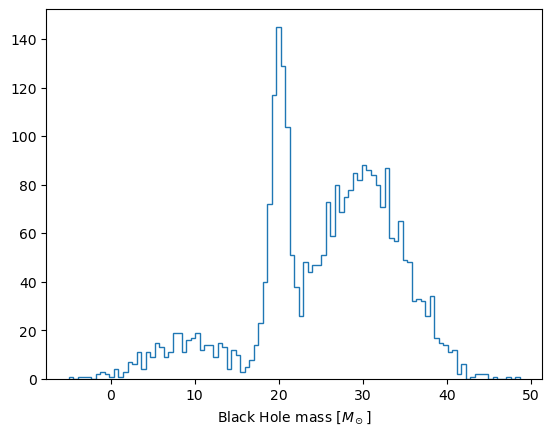

In [9]:
plt.hist(file, bins = 100, histtype = 'step')
plt.xlabel('Black Hole mass $[M_\odot]$')
print(file)


In [11]:
# fit models with 1-10 components
Ns = np.arange(1,10)

models = [GaussianMixture(N).fit(file) for N in Ns]

In [12]:
# compute the AIC
# the AIC is a statistical metric used to compare models
# the model with the lowest AIC is considered the best
AIC = [m.aic(file) for m in models]

Text(0, 0.5, 'information criterion')

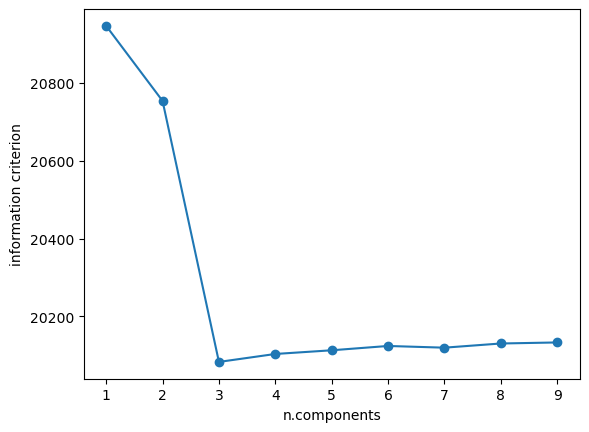

In [13]:
plt.plot(Ns, AIC,)
plt.scatter(Ns, AIC)

plt.xlabel('n.components')
plt.ylabel('information criterion')

In [16]:
print('The AIC is minimized for N =', Ns[np.argmin(AIC)])

The AIC is minimized for n = 3


<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_534/2847985003.py:12: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Black Hole mass $[M_\odot]$')


Text(0.5, 0, 'Black Hole mass $[M_\\odot]$')

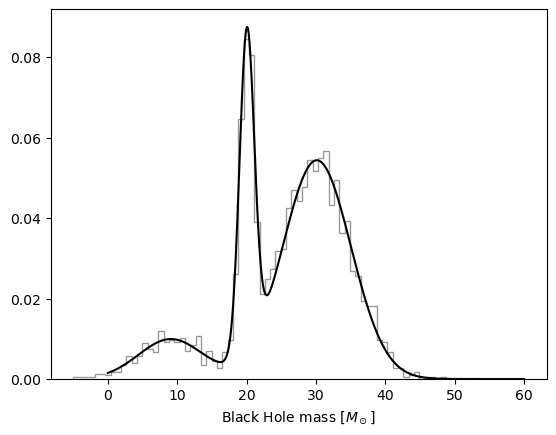

In [19]:
# specific solution
M_best = models[np.argmin(AIC)]

x = np.linspace(0,60,1000)
logprob = M_best.score_samples(x.reshape(-1,1))
pdf = np.exp(logprob)

plt.hist(file, 70, density=True, histtype='step', alpha=0.4, color='black')

plt.plot(x,pdf,'k')

plt.xlabel('Black Hole mass $[M_\odot]$')

<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_534/2240896896.py:9: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Black Hole mass $[M_\odot]$')


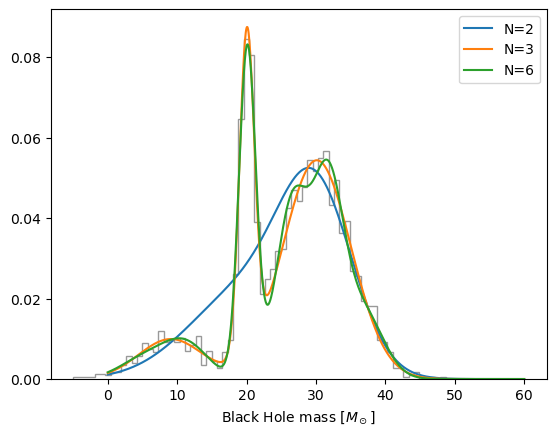

In [22]:
# compare results
plt.hist(file, 70, density=True, histtype='step', alpha=0.4, color='black')

for index in np.argmin(AIC)+np.array([-1,0,3]):
    
    logprob = models[index].score_samples(x.reshape(-1,1))
    plt.plot(x, np.exp(logprob), label='N='+str(Ns[index]))
    
plt.xlabel('Black Hole mass $[M_\odot]$')
plt.legend()

In [ ]:
\